# Project 1

source: StatsBomb open data on GitHub


goal: load competitions, matches and inspect structure

In [196]:
#importing the libraries we will use
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from mplsoccer import Pitch, VerticalPitch

In [197]:
path = 'C:/Users/Miranda/Desktop/Data/open-data-master/data'

### Functions

In [198]:
#function to read the json file and create a dataframe with the information of the matches, also it will ask the user to select the competition and season to analyze
def info_json(path):
    
    with open(path + '/competitions.json') as f:
        competitions = json.load(f)
        
    competition_id = []
    competition_name = []
    
    for competition in competitions:
        
        if competition['competition_id'] not in competition_id:
            competition_id.append(competition['competition_id'])  
              
        if competition['competition_name'] not in competition_name:
            competition_name.append(competition['competition_name'])
            
    df_competition = pd.DataFrame()
    df_competition['id'] = competition_id
    df_competition['Competition'] = competition_name
    df_competition.set_index('id', inplace=True)
    
    print('*'*38)
    print(df_competition, '\n')
    id_competition = int(input('Which competition do you want to analyze:'))
    
    season_id = []
    season_name = []

    for season in competitions:
        
        #we will filter the seasons of the selected competition
        if season['competition_id'] == id_competition:
            
            if season['season_id'] not in season_id:
                season_id.append(season['season_id'])
                
            if season['season_name'] not in season_name:
                season_name.append(season['season_name'])
                
    df_season = pd.DataFrame()
    df_season['id'] = season_id
    df_season['Season'] = season_name
    df_season.set_index('id', inplace=True)
    
    print('*'*38)
    print(df_season, '\n')
    id_season = int(input('Which season do you want to analyze: '))
    
    with open(path + '/matches/' + str(id_competition) + '/'+ str(id_season) + '.json', encoding='utf-8') as f:
        matches = json.load(f)
        
    df = pd.json_normalize(matches)
    
    columns = ['home_team.home_team_name','away_team.away_team_name','home_score','away_score', 
               'match_id','match_date','competition.competition_name','competition_stage.name']
    
    df = df[columns].copy()
    df.columns = ['home_team', 'away_team', 'home_score', 'away_score', 'match_id', 'match_date', 
                  'competition','stage']
    df.set_index('match_id', inplace=True)
    df.sort_values('match_date', inplace=True)
    
    return df

In [199]:
#function to extract the coordinates of the events and create new columns with the x and y coordinates, also it will drop the original location column
def coordinates(df):
    cols = [col for col in df.columns if col.__contains__('location')]
    cols_x = [col + '_x' for col in df.columns if col.__contains__('location')]
    cols_y = [col + '_y' for col in df.columns if col.__contains__('location')]
    
    for i in range(len(cols)):
        df[cols_x[i]] = df[cols[i]].replace(np.nan,0).apply(lambda x: x[0] if x != 0 else np.nan)
        df[cols_y[i]] = df[cols[i]].replace(np.nan,0).apply(lambda x: x[1] if x != 0 else np.nan)
    
    df.drop(columns=cols, axis=1, inplace=True)
    
    return df

In [200]:
#function to read the json file and create a dataframe with the information of the events, also it will ask the user to select the event to analyze
def event_data(path, match_id, event=True):
   file_name = '/events/'+ str(match_id) + '.json'
   with open(path + file_name, encoding='utf-8') as f:
      data = json.load(f)
      
   df = pd.json_normalize(data, sep='_')
   df = coordinates(df)
   
   if event == True:
      print(df.type_name.unique(), '\n')
      event = input('Which event do you want to analyze: ')
      df = df[df.type_name == event]
      
   return df


In [205]:
#function to plot the shots of the selected matches
def plot_event_shots(matches, shots):
    
    fig, ax = plt.subplots(figsize=(12, 8))
    pitch = Pitch(pitch_color='white', line_color='black')
    pitch.draw(ax=ax)
    
    for i in range(len(shots)):
    
        if shots.team_name.values[i] == matches.home_team.values[0]:
            if shots.shot_outcome_name.values[i] == 'Goal':
                pitch.scatter(120 - shots.location_x.values[i], 
                              80 -shots.location_y.values[i], 
                              ax=ax,
                              color='red',
                              marker='h', 
                              s= shots.shot_statsbomb_xg.values[i]*1000)
                plt.text(120 - shots.location_x.values[i],
                         80 -shots.location_y.values[i],
                         shots.player_name.values[i])

            else:
                pitch.scatter(120 -shots.location_x.values[i], 
                              80 - shots.location_y.values[i], 
                              ax=ax,
                              color='red',
                              marker='h', 
                              s= shots.shot_statsbomb_xg.values[i]*1000,
                              alpha=0.3) 

        elif shots.team_name.values[i] == matches.away_team.values[0]:
            if shots.shot_outcome_name.values[i] == 'Goal':
                pitch.scatter(shots.location_x.values[i],
                              shots.location_y.values[i],
                              ax=ax,
                              color='blue',
                              marker='h',
                              s= shots.shot_statsbomb_xg.values[i]*1000)
                plt.text(shots.location_x.values[i],
                        shots.location_y.values[i],
                        shots.player_name.values[i])

            else:
                pitch.scatter(shots.location_x.values[i],
                              shots.location_y.values[i],
                              ax=ax,
                              color='blue',
                              marker='h',
                              s= shots.shot_statsbomb_xg.values[i]*1000,
                              alpha=0.3)
                
    plt.text(15, 5, matches.home_team.values[0] + ' shots')
    plt.text(80, 5, matches.away_team.values[0] + ' shots')
    plt.title('{} \n {} - {} {} X {} {}'.format(matches.competition.values[0], 
                                                matches.match_date.values[0], 
                                                matches.home_team.values[0],
                                                matches.home_score.values[0],
                                                matches.away_score.values[0], 
                                                matches.away_team.values[0]),
    fontsize=16)
    plt.show()

In [202]:
matches = info_json(path)
matches

**************************************
                  Competition
id                           
9               1. Bundesliga
1267   African Cup of Nations
16           Champions League
223              Copa America
87               Copa del Rey
37    FA Women's Super League
1470       FIFA U20 World Cup
43             FIFA World Cup
1238      Indian Super league
11                    La Liga
81           Liga Profesional
7                     Ligue 1
44        Major League Soccer
116     North American League
49                       NWSL
2              Premier League
12                    Serie A
55                  UEFA Euro
35         UEFA Europa League
53          UEFA Women's Euro
72          Women's World Cup 

**************************************
        Season
id            
4    2018/2019
1    2017/2018
2    2016/2017
27   2015/2016
26   2014/2015
25   2013/2014
24   2012/2013
23   2011/2012
22   2010/2011
21   2009/2010
41   2008/2009
39   2006/2007
37   2004/2005
44   

,home_team,away_team,home_score,away_score,match_date,competition,stage
match_id,,,,,,,
18244,Juventus,Real Madrid,1,4,2017-06-03,Champions League,Final


In [203]:
shots = event_data(path, matches.index[0])
shots

['Starting XI' 'Half Start' 'Pass' 'Ball Receipt*' 'Carry' 'Clearance'
 'Pressure' 'Block' 'Dribbled Past' 'Dribble' 'Foul Committed' 'Foul Won'
 'Miscontrol' 'Ball Recovery' 'Dispossessed' 'Duel' 'Shot' 'Goal Keeper'
 'Interception' 'Offside' 'Tactical Shift' 'Injury Stoppage' 'Half End'
 'Bad Behaviour' 'Substitution' '50/50'] 



,id,index,period,timestamp,minute,second,possession,duration,type_id,type_name,...,location_x,location_y,pass_end_location_x,pass_end_location_y,carry_end_location_x,carry_end_location_y,shot_end_location_x,shot_end_location_y,goalkeeper_end_location_x,goalkeeper_end_location_y
154,edbeec9b-c1a4-46dd-9b99-1df1d9a8e6fa,155,1,00:02:50.064,2,50,9,0.938222,16,Shot,...,106.0,37.0,NaN,NaN,NaN,NaN,120.0,41.9,NaN,NaN
188,31367083-181d-406d-84e0-693e1a1373a6,189,1,00:03:20.951,3,20,14,0.845400,16,Shot,...,92.0,49.0,NaN,NaN,NaN,NaN,119.0,39.9,NaN,NaN
318,1a989d90-d770-4ac8-898d-5f420d5bc8f1,319,1,00:06:02.514,6,2,28,0.713000,16,Shot,...,98.0,35.0,NaN,NaN,NaN,NaN,118.0,37.2,NaN,NaN
937,af7c575a-50d8-419a-89a5-b4abbc11e3c9,938,1,00:19:38.935,19,38,54,0.740698,16,Shot,...,105.0,44.0,NaN,NaN,NaN,NaN,119.0,36.8,NaN,NaN
1039,e41ba6de-15b2-4695-aa3a-1713bf34291b,1040,1,00:22:24.726,22,24,57,0.243900,16,Shot,...,105.0,51.0,NaN,NaN,NaN,NaN,108.0,49.0,NaN,NaN
1196,f52a193e-eacc-49cc-9082-599b236a3116,1197,1,00:25:37.955,25,37,62,0.116800,16,Shot,...,100.0,39.0,NaN,NaN,NaN,NaN,102.0,39.0,NaN,NaN
1244,2fed9dfd-c530-4567-b3e3-915490a97b84,1245,1,00:26:20.804,26,20,64,1.546950,16,Shot,...,106.0,30.0,NaN,NaN,NaN,NaN,120.0,43.2,NaN,NaN
1377,7c5b5cfa-918e-426f-8edb-e7be2e64ff7c,1378,1,00:30:28.596,30,28,72,0.631293,16,Shot,...,105.0,42.0,NaN,NaN,NaN,NaN,110.0,43.0,NaN,NaN
1417,7d9938d4-a094-4d47-b6dd-14326ac1cd48,1418,1,00:32:20.174,32,20,76,0.128500,16,Shot,...,112.0,45.0,NaN,NaN,NaN,NaN,115.0,29.0,NaN,NaN
1480,b326263c-945a-48f0-965c-676ceb7ea244,1481,1,00:34:04.438,34,4,78,0.335700,16,Shot,...,89.0,50.0,NaN,NaN,NaN,NaN,99.0,48.0,NaN,NaN


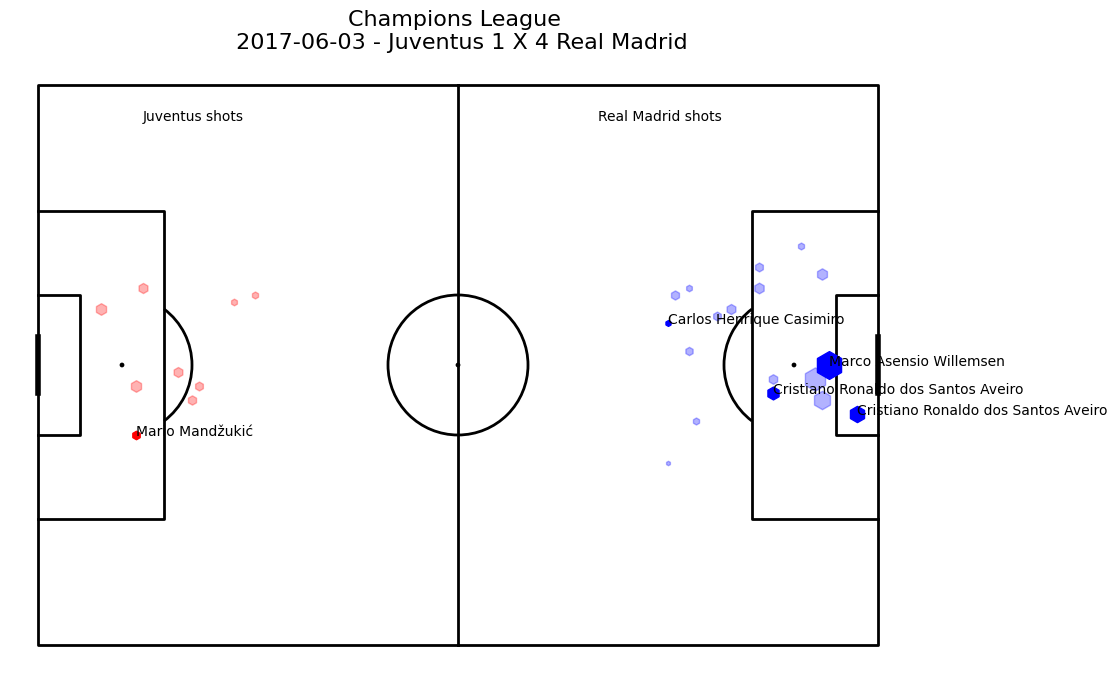

In [206]:
plot_event_shots(matches, shots)